# Decision Trees Lab
In this lab, we will practice implementing decision trees and various ensembles, such as XGBoost.

All  of  the  programming  assignments  are  to  be  done  in  Python  using  additional  libraries  specified  in  the  assignments.  There  are many  libraries  available,  some  of  which  we  will  be  using,  and  you  are  welcome  to  use  them  with  one  exception:  if  the  library  or  a  function  within  it  performs  the  specific  function  you  are  asked  to  code,  you  may  not  use  that  other  than  as  a  reference  to  compare  against. All  of  the  code  you  submit  must  be  your  own. Once you have completed an assignment, turn in your jupyter notebook with all the outputs shown.


### Preliminaries

Before you begin, make sure you have a properly operating Python environment with the Pandas, NumPy, Matplotlib, and Sci-kit Learn packages installed. If setup correctly, the following line of code should run without error:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

For this lab, you will also want the XGBoost library installed. It has an API designed to mimick Sci-kit Learn. If you don't already have it, make sure to `pip install xgboost`

In [8]:
#!pip install xgboost

import xgboost

Also make sure you have the following datasets downloaded from the assignment page and placed in a `datasets/` directory of your project folder. **Please do not change the folder structure to minimize issues when grading.**

In [12]:
heart_fn = "./datasets/heart_edited.csv"
credit_fn = "./datasets/german_credit_data.csv"
income_fn = "./datasets/adult_income_edited.csv"
driver_fn = "./datasets/safe_driver.csv"

Datasets descriptions

- Heart: A dataset of participants with common vital signs and physical measurements with the goal of predicting whether the participant has heart disease.
- Credit: The financial information of various individuals with a goal of predicting credit risk.
- Income: Predicts the financial status of various individuals based on personal information.
- Driver: Various information about drivers in Brazil with the goal of predicting whether an individual needed to file an insurance claim.

## Part 1: Implement Decision Tree Splitting

To begin the lab, you will improve your understanding of decision tree splits by implementing your own splitting function from scratch. Fill in the functions below to calculate gini impurity to evaluate decision splits. I have already implemented the code that retrieves all possible splits. You need to implement the `_gini_impurity_of_split` function. This takes the labels in the left leaf and labels of the right leaf as inputs, calculates the impurity of each leaf from those labels, and then determines the overall impurity of the split. You can assume a binary classifier for simplicity.

To test you algorithm, we will be using the heart disease dataset. The testing code is provided in a separate cell to evaluate the effectiveness of your model. You can also compare to sklearn's DecisionTree algorithm to verify your results.

In [15]:
class myDecisionTreeClassifier:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)

    def predict(self, X):
        def _predict_sample(sample, node):
            if node.value is not None:
                return node.value
            if sample[node.feature] <= node.threshold:
                return _predict_sample(sample, node.left)
            else:
                return _predict_sample(sample, node.right)

        predictions = [_predict_sample(sample, self.tree) for sample in X]
        return np.array(predictions)
    
    def score(self, predictions, targets):
        return np.mean(predictions == targets)

    class _tree_node():
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value

    def _gini_impurity_of_split(self, y_left, y_right):
        # Calculate the Gini impurity for a split
        def gini(y):
            classes, counts = np.unique(y, return_counts=True)
            impurity = 1.0
            total = len(y)
            for count in counts:
                prob = count / total
                impurity -= prob**2
            return impurity

        total_left = len(y_left)
        total_right = len(y_right)

        if total_left == 0 or total_right == 0:
            return 0
        
        total_left_right = total_left + total_right
        prob_left = total_left / total_left_right
        prob_right = total_right / total_left_right
        
        return prob_left * gini(y_left) + prob_right * gini(y_right)

    def _best_split(self, X, y):
        # Initialize variables to track the best split
        best_gini = float('inf')
        best_feature = None
        best_threshold = None

        n_samples, n_features = X.shape

        # Iterate over all features
        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                # Split the data
                left_mask = X[:, feature] <= threshold
                right_mask = X[:, feature] > threshold

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                # Calculate Gini impurity for the split
                gini_split = self._gini_impurity_of_split(y_left, y_right)

                # Update the best split if needed
                if gini_split < best_gini:
                    best_gini = gini_split
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold
    

    def _build_tree(self, X, y, depth=0):
        # Check stopping conditions
        if len(np.unique(y)) == 1:
            return self._tree_node(value=y[0])
        if depth >= self.max_depth:
            return self._tree_node(value=np.bincount(y).argmax())

        # Find the best split
        feature, threshold = self._best_split(X, y)
        if feature is None:
            return self._tree_node(value=np.bincount(y).argmax())

        # Split the data
        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return self._tree_node(feature=feature, threshold=threshold, left=left_child, right=right_child)

In [16]:
# Test the decision tree on the heart disease dataset
heart_df = pd.read_csv(income_fn)
X_heart = heart_df.drop(columns=["Has Heart Disease"]).values
y_heart = heart_df["Has Heart Disease"].values

# Train the decision tree
tree = myDecisionTreeClassifier(max_depth=3)
tree.fit(X_heart, y_heart)

# Make predictions
predictions = tree.predict(X_heart)

# Evaluate the model
accuracy = tree.score(predictions, y_heart)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.85


In [17]:
# Compare to sklearn's DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
sk_tree = DecisionTreeClassifier(max_depth=3)
sk_tree.fit(X_heart, y_heart)
sk_predictions = sk_tree.predict(X_heart)
sk_accuracy = np.mean(sk_predictions == y_heart)
print(f"Sklearn Accuracy: {sk_accuracy:.2f}")

Sklearn Accuracy: 0.85


## Part 2: Trees and Ensembles

In this part of the lab, you will practice using the various decision tree parameters and ensemble methods. You will be trying to acheive as high an accuracy as possible on the credit dataset. We will not have a separate test set for this part, so report the accuracy of the model on training data when using 3-fold cross validation and paramter tuning.

Your variation of models should include standard decision trees, as well as ensembles like:
- RandomForest
- AdaBoost
- XGBoost

You should consider parameters such as:
- Number of Trees
- Max Depth of Trees
- Learning Rate (for boosting methods)
- Max Features per Tree

Try at least 3 variations of Classifiers with cross validation and parameter tuning to obtain the highest possible accuracy on the training set. Once you have found your best model, also plot or print out the feature importance to answer the follow up question.

In [ ]:
# Test the decision tree on the credit dataset
credit_df = pd.read_csv(credit_fn)
# Removed Unnamed column if exists
if 'Unnamed: 0' in credit_df.columns:
    credit_df = credit_df.drop(columns=['Unnamed: 0'])

# One-hot encode categorical variables
credit_df = pd.get_dummies(credit_df, drop_first=True)

# Prepare features and labels
X_credit = credit_df.drop(columns=["Risk_good"]).values
y_credit = credit_df["Risk_good"].values

Standard Decision Tree
Standard training set score:  1.0
              precision    recall  f1-score   support

       False       0.34      0.36      0.35        59
        True       0.72      0.71      0.72       141

    accuracy                           0.60       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.61      0.60      0.61       200

[[ 21  38]
 [ 41 100]]
Random forest best parameters found:  {'max_depth': 9, 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 200}
Random forest training set score:  0.8125
              precision    recall  f1-score   support

       False       0.60      0.20      0.30        59
        True       0.74      0.94      0.83       141

    accuracy                           0.72       200
   macro avg       0.67      0.57      0.57       200
weighted avg       0.70      0.72      0.67       200

[[ 12  47]
 [  8 133]]

Top Features for RandomForestClassifier:
1. Credit amount (0.2489)
2. Age (0.

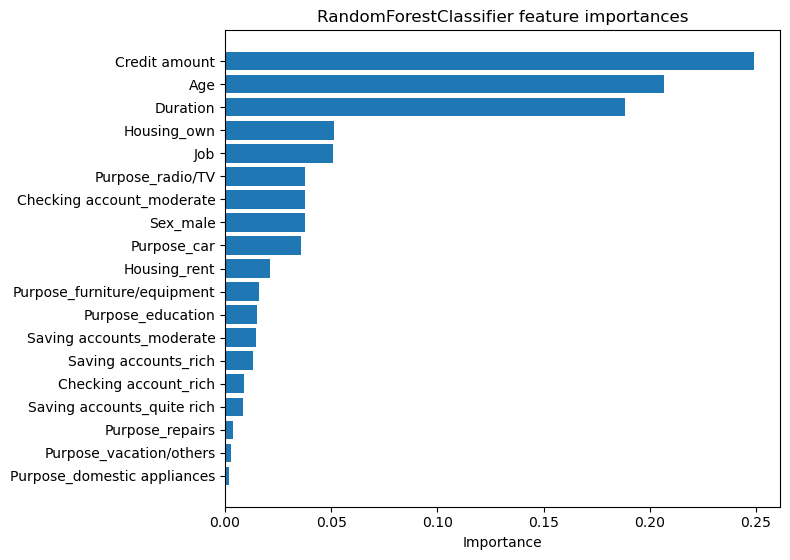

AdaBoost best parameters found:  {'learning_rate': 0.1, 'n_estimators': 175}
AdaBoost training set score:  0.70875
              precision    recall  f1-score   support

       False       1.00      0.07      0.13        59
        True       0.72      1.00      0.84       141

    accuracy                           0.72       200
   macro avg       0.86      0.53      0.48       200
weighted avg       0.80      0.72      0.63       200

[[  4  55]
 [  0 141]]

Top Features for AdaBoostClassifier:
1. Duration (0.4101)
2. Age (0.1989)
3. Credit amount (0.1552)
4. Housing_own (0.1190)
5. Purpose_radio/TV (0.0626)
6. Saving accounts_rich (0.0319)
7. Checking account_moderate (0.0224)
8. Purpose_repairs (0.0000)
9. Purpose_vacation/others (0.0000)
10. Purpose_furniture/equipment (0.0000)
11. Purpose_education (0.0000)
12. Saving accounts_quite rich (0.0000)
13. Checking account_rich (0.0000)
14. Purpose_domestic appliances (0.0000)
15. Purpose_car (0.0000)
16. Sex_male (0.0000)
17. Housing

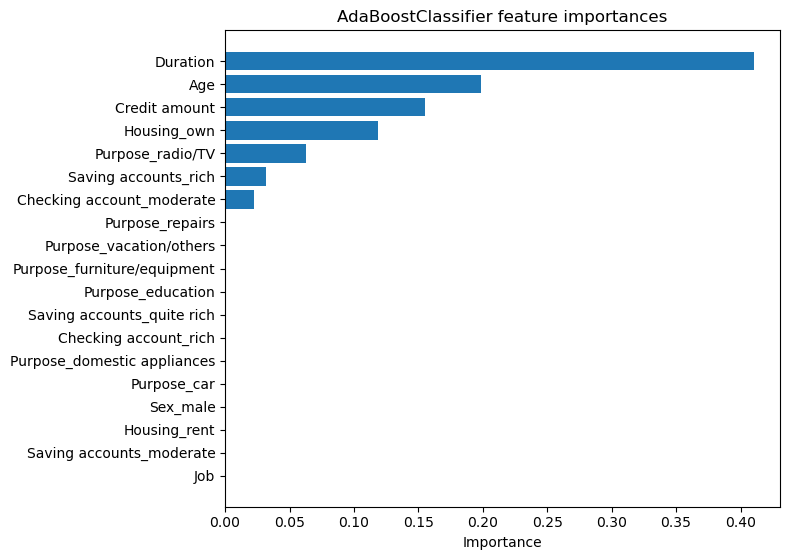

Best parameters found:  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 60}
XGBoost training set score:  0.79875
              precision    recall  f1-score   support

       False       0.60      0.20      0.30        59
        True       0.74      0.94      0.83       141

    accuracy                           0.72       200
   macro avg       0.67      0.57      0.57       200
weighted avg       0.70      0.72      0.67       200

[[ 12  47]
 [  8 133]]

Top Features for XGBClassifier:
1. Housing_own (0.1013)
2. Purpose_repairs (0.0905)
3. Duration (0.0855)
4. Purpose_car (0.0716)
5. Age (0.0701)
6. Saving accounts_rich (0.0671)
7. Purpose_radio/TV (0.0628)
8. Credit amount (0.0578)
9. Job (0.0533)
10. Purpose_education (0.0465)
11. Sex_male (0.0462)
12. Purpose_furniture/equipment (0.0462)
13. Checking account_rich (0.0439)
14. Housing_rent (0.0420)
15. Saving accounts_moderate (0.0417)
16. Checking account_moderate (0.0406)
17. Saving accounts_quite rich (0.0329)
18. Pur

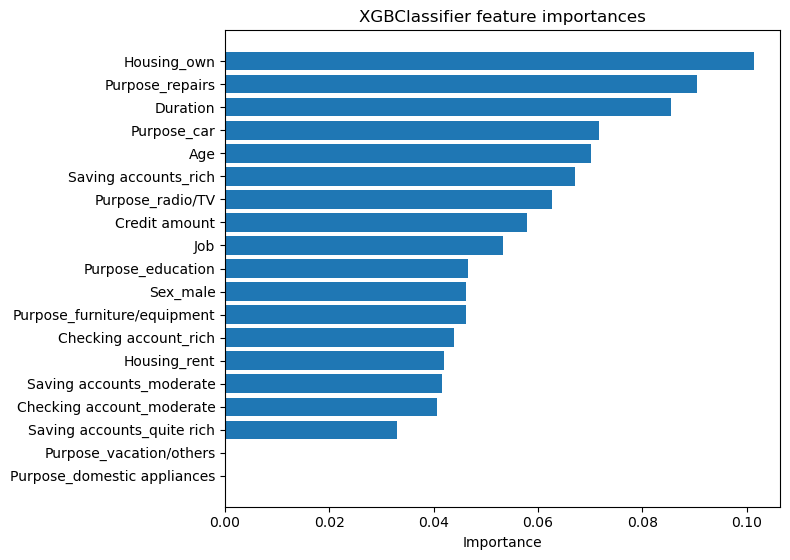

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_credit, y_credit, test_size=0.2, random_state=42)

from sklearn.metrics import classification_report, confusion_matrix

# standard decision tree
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)
pred = dtree.predict(X_test)

print("Standard Decision Tree")
print("Standard training set score: ", dtree.score(X_train, y_train))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

# random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200], # 50,100,150,175,200,225,250
    'max_depth': [9], # 5,8,9,10,12
    'min_samples_split': [3], # 1,2,3,5,10
    'min_samples_leaf': [3], # 1,2,3,4,5
}

rfc = RandomForestClassifier()
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=3)
grid_search.fit(X_train, y_train)
print("Random forest best parameters found: ", grid_search.best_params_)
best_rfc = grid_search.best_estimator_

print("Random forest training set score: ", best_rfc.score(X_train, y_train))

predictions = best_rfc.predict(X_test)
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

def show_importances(estimator):
    if not hasattr(estimator, "feature_importances_"):
        print(f"{estimator.__class__.__name__} has no attribute 'feature_importances_'")
        return
    importances = estimator.feature_importances_
    indices = np.argsort(importances)[::-1]
    n = len(importances)
    print(f"\nTop Features for {estimator.__class__.__name__}:")
    feature_names = credit_df.drop(columns=["Risk_good"]).columns.to_list()
    for rank, idx in enumerate(indices[:n], start=1):
        print(f"{rank}. {feature_names[idx]} ({importances[idx]:.4f})")
    plt.figure(figsize=(8, max(2, n*0.3)))
    plt.title(f"{estimator.__class__.__name__} feature importances")
    plt.barh(range(n), importances[indices[:n]][:n][::-1])
    plt.yticks(range(n), [feature_names[i] for i in indices[:n]][:n][::-1])
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

show_importances(best_rfc)

# ada boost
from sklearn.ensemble import AdaBoostClassifier

base_estimator = DecisionTreeClassifier(max_depth=1)
ada = AdaBoostClassifier(estimator=base_estimator)
param_dist = {
    'n_estimators': [175], # 50,100,150,175,200,225,250
    'learning_rate': [0.1] # 0.01,0.05,0.1,0.15,1.0
}

random_search = GridSearchCV(estimator=ada, param_grid=param_dist, cv=3)
random_search.fit(X_train, y_train)
print("AdaBoost best parameters found: ", random_search.best_params_)

best_ada = random_search.best_estimator_

print("AdaBoost training set score: ", best_ada.score(X_train, y_train))
predictions = best_ada.predict(X_test)
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

show_importances(best_ada)

# xg boost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

xgb = XGBClassifier(eval_metric='logloss')

if y_train.dtype == 'object':
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)

param_grid = {
    'n_estimators': [60], # 25,40,50,60,75,100,200
    'max_depth': [4], # 2,3,4,5,10
    'learning_rate': [0.05] # 0.05,0.1,0.15,1.0
}

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3)
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

best_xgb = grid_search.best_estimator_
print("XGBoost training set score: ", best_xgb.score(X_train, y_train))
predictions = best_xgb.predict(X_test)
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

show_importances(best_xgb)

#### Answer the following questions in the markdown cell below: 

#### Which model worked best? Why do you think this model worked best? Is this what you expected? Which features ended up being most important? Are these what you expected?

Random forest turned out to be the best model by slim margins. I believe this model worked best as it does better with the smaller datasets by pulling random pieces of data to train on. With a smaller dataset of 200 rows, random forest is expected to do well. The features that were the most important were duration, credit amount, and age. These are to be expected.

## Part 3: Analyzing Training Time

For this last part of the lab, we will cover a very practical aspect of machine learning algorithms: how an algorithm's training time scales with data size. We will analyze three datasets listed of very different sizes:

- Heart: over 1,000 rows
- Income: over 30,000 rows
- Driver: over 500,000 rows

Your task for this part of the lab is not to measure performance in terms of accuracy (you are welcome to compute it, but you don't have to), and no cross validation or parameter tuning is needed. Instead, we simply want to get a picture of training times for different algorithms running on larger and larger dataset.

For this part of the lab, please run each of the following model configurations on the four datasets listed above:

- A Gaussian Naive Bayes Model
- A Random Forest Model with 100 Trees of Max Depth 5
- An XGBoost Model with 100 Trees of Max Depth 5
- A KNN model with k=3 (**report prediction time on the training dataset**)
- A Support Vector Machine with Radial Basis Function Kernel

For each model and dataset, run the `model.fit()` function within a timing loop (example provided) to get the training time of each model. Output these times in the notebook. Lastly, output a line plot that has the training times of each model when compared to dataset size. Place all 5 models on the same plot and use colors and legends to distinguish between them.

*Note*: For consistency between each model, we will label encode all categorical values. This wouldn't always be best for model accuracy, but is sufficient for getting a picture of timings.

**Warning:** SVM may not converge in a reasonable time on the last dataset. If it runs for more than 5 minutes, you are welcome to abort it and make the plot without it for the last dataset.

In [54]:
# Load heart disease dataset
heart_df = pd.read_csv(heart_fn)

# Label encode categorical variables if needed
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for column in heart_df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    heart_df[column] = le.fit_transform(heart_df[column])
    label_encoders[column] = le

# Get features and labels
X_heart = heart_df.drop(columns=["Has Heart Disease"]).values
y_heart = heart_df["Has Heart Disease"].values

# Example Timing Loop for Gaussian Naive Bayes
from time import time
from sklearn.naive_bayes import GaussianNB
start = time()
nb_model = GaussianNB()
nb_model.fit(X_heart,y_heart)
end = time()
time_nb_heart = end-start
print(f"Heart Gaussian Naive Bayes Training Time: {time_nb_heart:.3f} seconds")

# Random forest
start = time()
forest_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
forest_model.fit(X_heart,y_heart)
end = time()
time_forest_heart = end-start
print(f"Heart Random Forest Training Time: {time_forest_heart:.3f} seconds")

# XGBoost
start = time()
xg_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
xg_model.fit(X_heart,y_heart)
end = time()
time_xg_heart = end-start
print(f"Heart XGBoost Training Time: {time_xg_heart:.3f} seconds")

# KNN
from sklearn.neighbors import KNeighborsClassifier
start = time()
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_heart,y_heart)
start_predict = time()
predictions = knn_model.predict(X_heart)
end = time()
time_knn_heart = end-start
time_knn_predict_heart = end-start_predict
print(f"Heart KNN Total Time: {time_knn_heart:.3f} seconds")
print(f"Heart KNN Predictions Time: {time_knn_predict_heart:.3f} seconds")

# SVM
from sklearn.svm import SVC
start = time()
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_heart,y_heart)
end = time()
time_svm_heart = end-start
print(f"Heart SVM Training Time: {time_svm_heart:.3f} seconds")

Heart Gaussian Naive Bayes Training Time: 0.004 seconds
Heart Random Forest Training Time: 0.579 seconds
Heart XGBoost Training Time: 0.142 seconds
Heart KNN Total Time: 0.052 seconds
Heart KNN Predictions Time: 0.044 seconds
Heart SVM Training Time: 0.090 seconds


In [55]:
# Load the Adult Income Dataset
income_df = pd.read_csv(income_fn)

# Label encode categorical variables if needed
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for column in income_df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    income_df[column] = le.fit_transform(income_df[column])
    label_encoders[column] = le

# Get features and labels
X_income = income_df.drop(columns=["income"]).values
y_income = income_df["income"].values

# Gaussian NB
start = time()
nb_model = GaussianNB()
nb_model.fit(X_income,y_income)
end = time()
time_nb_income = end-start
print(f"Income Gaussian Naive Bayes Training Time: {time_nb_income:.3f} seconds")

# Random forest
start = time()
forest_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
forest_model.fit(X_income,y_income)
end = time()
time_forest_income = end-start
print(f"Income Random Forest Training Time: {time_forest_income:.3f} seconds")

# XGBoost
start = time()
xg_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
xg_model.fit(X_income,y_income)
end = time()
time_xg_income = end-start
print(f"Income XGBoost Training Time: {time_xg_income:.3f} seconds")

# KNN
from sklearn.neighbors import KNeighborsClassifier
start = time()
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_income,y_income)
start_predict = time()
predictions = knn_model.predict(X_income)
end = time()
time_knn_income = end-start
time_knn_predict_income = end-start_predict
print(f"Income KNN Total Time: {time_knn_income:.3f} seconds")
print(f"Income KNN Predictions Time: {time_knn_predict_income:.3f} seconds")

# SVM
from sklearn.svm import SVC
start = time()
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_income,y_income)
end = time()
time_svm_income = end-start
print(f"Income SVM Training Time: {time_svm_income:.3f} seconds")

Income Gaussian Naive Bayes Training Time: 0.015 seconds
Income Random Forest Training Time: 2.552 seconds
Income XGBoost Training Time: 0.245 seconds
Income KNN Total Time: 3.760 seconds
Income KNN Predictions Time: 3.563 seconds
Income SVM Training Time: 42.493 seconds


In [56]:
# Load the Safe Driver Dataset
driver_df = pd.read_csv(driver_fn)

X_driver = driver_df.drop(columns=["id","target"])
y_driver = driver_df["target"]

# Gaussian NB
start = time()
nb_model = GaussianNB()
nb_model.fit(X_driver,y_driver)
end = time()
time_nb_driver = end-start
print(f"Driver Gaussian Naive Bayes Training Time: {time_nb_driver:.3f} seconds")

# Random forest
start = time()
forest_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
forest_model.fit(X_driver,y_driver)
end = time()
time_forest_driver = end-start
print(f"Driver Random Forest Training Time: {time_forest_driver:.3f} seconds")

# XGBoost
start = time()
xg_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
xg_model.fit(X_driver,y_driver)
end = time()
time_xg_driver = end-start
print(f"Driver XGBoost Training Time: {time_xg_driver:.3f} seconds")

# Separate dataset for SVM and KNN with less features so they don't blow up your computer
X_driver_feat5 = X_driver[['ps_ind_01','ps_ind_02_cat','ps_ind_03','ps_ind_04_cat','ps_ind_05_cat']]

# KNN
from sklearn.neighbors import KNeighborsClassifier
start = time()
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_driver_feat5,y_driver)
start_predict = time()
predictions = knn_model.predict(X_driver_feat5)
end = time()
time_knn_driver = end-start
time_knn_predict_driver = end-start_predict
print(f"Driver KNN Total Time: {time_knn_driver:.3f} seconds")
print(f"Driver KNN Predictions Time: {time_knn_predict_driver:.3f} seconds")

# SVM
from sklearn.svm import SVC
start = time()
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_driver_feat5,y_driver)
end = time()
time_svm_driver = end-start
print(f"Driver SVM Training Time: {time_svm_driver:.3f} seconds")

Driver Gaussian Naive Bayes Training Time: 1.467 seconds
Driver Random Forest Training Time: 123.439 seconds
Driver XGBoost Training Time: 6.850 seconds
Driver KNN Total Time: 303.754 seconds
Driver KNN Predictions Time: 301.290 seconds
Driver SVM Training Time: 2829.711 seconds


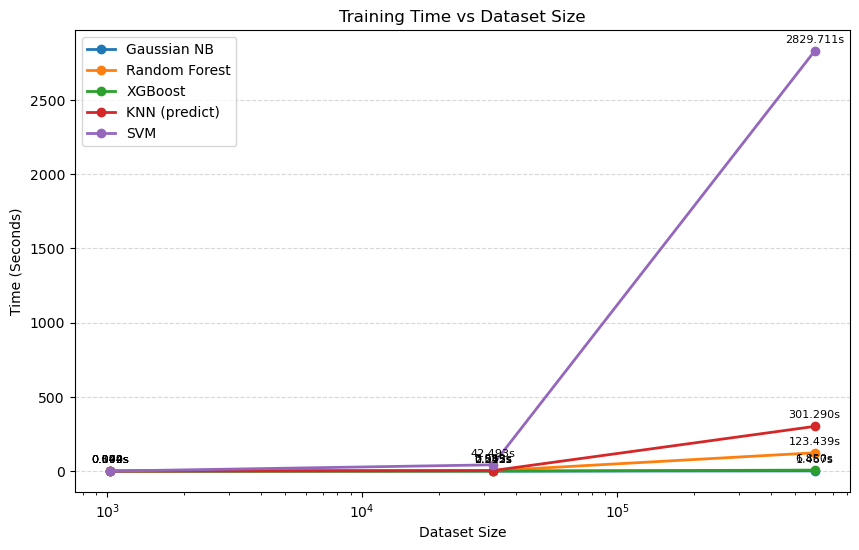

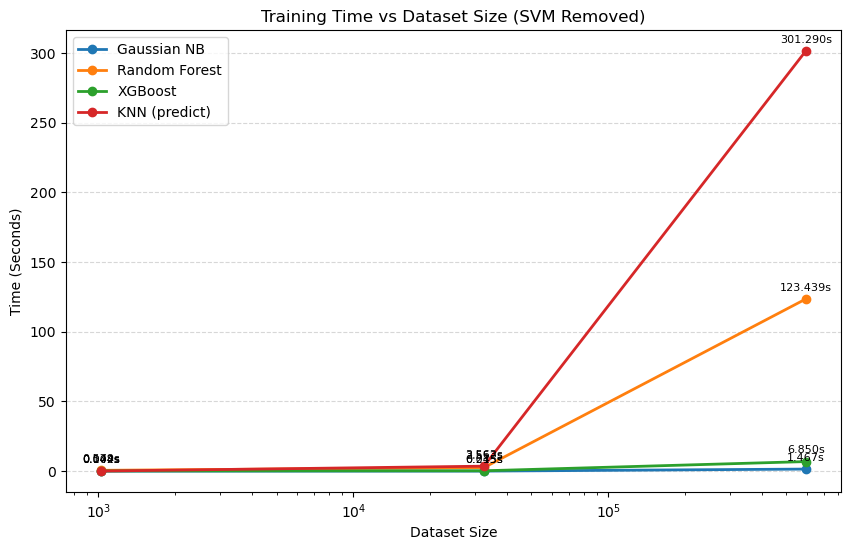

In [70]:
dataset_sizes = [len(X_heart), len(X_income), len(X_driver)]
dataset_labels = ["Heart", "Income", "Driver"]
x = np.array(dataset_sizes)

nb_times = [time_nb_heart, time_nb_income, time_nb_driver]
rf_times = [time_forest_heart, time_forest_income, time_forest_driver]
xg_times = [time_xg_heart, time_xg_income, time_xg_driver]
knn_times = [time_knn_predict_heart, time_knn_predict_income, time_knn_predict_driver]
svm_times = [time_svm_heart, time_svm_income, time_svm_driver]

models = {
    "Gaussian NB": nb_times,
    "Random Forest": rf_times,
    "XGBoost": xg_times,
    "KNN (predict)": knn_times,
    "SVM": svm_times
}

plt.figure(figsize=(10,6))
colors = ["C0","C1","C2","C3","C4"]
for (name, times), c in zip(models.items(), colors):
    y = np.array(times, dtype=float)
    plt.plot(x, y, marker='o', label=name, color=c, linewidth=2, markersize=6)

plt.xlabel("Dataset Size")
plt.ylabel("Time (Seconds)")
plt.title("Training Time vs Dataset Size")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.xscale('log')

for xi_idx, xi in enumerate(x):
    for name, times in models.items():
        t = times[xi_idx]
        if not (isinstance(t, float) and np.isnan(t)):
            plt.annotate(f"{t:.3f}s", (xi, t), textcoords="offset points", xytext=(0,6), ha='center', fontsize=8)
plt.show()

# line plot without SVM outlier
models = {
    "Gaussian NB": nb_times,
    "Random Forest": rf_times,
    "XGBoost": xg_times,
    "KNN (predict)": knn_times
}

plt.figure(figsize=(10,6))
colors = ["C0","C1","C2","C3","C4"]
for (name, times), c in zip(models.items(), colors):
    y = np.array(times, dtype=float)
    plt.plot(x, y, marker='o', label=name, color=c, linewidth=2, markersize=6)

plt.xlabel("Dataset Size")
plt.ylabel("Time (Seconds)")
plt.title("Training Time vs Dataset Size (SVM Removed)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.xscale('log')

for xi_idx, xi in enumerate(x):
    for name, times in models.items():
        t = times[xi_idx]
        if not (isinstance(t, float) and np.isnan(t)):
            plt.annotate(f"{t:.3f}s", (xi, t), textcoords="offset points", xytext=(0,6), ha='center', fontsize=8)
plt.show()

#### Answer the following questions in the markdown cell below: 

#### What do you notice about the training times of each model? Which models scale well with size? Which models do not? If you had a very large dataset, which models would you try first? What other things might you try to reduce training time on large datasets? Why is comparing KNN prediction time on a dataset not quite a fair comparison to training time?

The training times of each model increases at different rates based on the dataset size. Gaussian Naive Bayes and XGBoost tend to do well with datasets at scale. With very large datasets, Gaussian Naive Bayes and XGBoost would be the models to try first. To reduce training time on datasets, you can reduce the amount of features to train on. Comparing KNN prediction time to training time on a dataset is not very fair as KNN training is just storing the data, not analyzing it like the prediction phase does.